In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs("data", exist_ok=True)

In [35]:
df.to_csv("data/sales.csv", index=False)

In [28]:
df = pd.DataFrame({
    "order_id": [1,2,3,4,5,6,7,8,9,10],
    "date": [
        "2024-01-01","2024-01-03","2024-01-10",
        "2024-02-05","2024-02-10","2024-02-15",
        "2024-03-01","2024-03-05","2024-03-10","2024-03-15"
    ],
    "product": ["A","B","A","A","B","C","A","C","B","A"],
    "category": ["tech","tech","tech","tech","tech","home","tech","home","tech","tech"],
    "price": [100,200,100,100,200,150,100,150,200,100],
    "quantity": [1,2,1,3,1,2,1,1,2,2]
})


In [29]:
df

,order_id,date,product,category,price,quantity
0,1,2024-01-01,A,tech,100,1
1,2,2024-01-03,B,tech,200,2
2,3,2024-01-10,A,tech,100,1
3,4,2024-02-05,A,tech,100,3
4,5,2024-02-10,B,tech,200,1
5,6,2024-02-15,C,home,150,2
6,7,2024-03-01,A,tech,100,1
7,8,2024-03-05,C,home,150,1
8,9,2024-03-10,B,tech,200,2
9,10,2024-03-15,A,tech,100,2


In [30]:
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["price"] * df["quantity"]
df

,order_id,date,product,category,price,quantity,revenue
0,1,2024-01-01,A,tech,100,1,100
1,2,2024-01-03,B,tech,200,2,400
2,3,2024-01-10,A,tech,100,1,100
3,4,2024-02-05,A,tech,100,3,300
4,5,2024-02-10,B,tech,200,1,200
5,6,2024-02-15,C,home,150,2,300
6,7,2024-03-01,A,tech,100,1,100
7,8,2024-03-05,C,home,150,1,150
8,9,2024-03-10,B,tech,200,2,400
9,10,2024-03-15,A,tech,100,2,200


In [5]:
df = df.set_index("date")
revenue_by_month = df.resample("ME")["revenue"].sum()
revenue_by_month

date
2024-01-31    600
2024-02-29    800
2024-03-31    850
Freq: ME, Name: revenue, dtype: int64

1. Dynamika przychodów:
Przychody rosły w każdym kolejnym miesiącu: z 600 w styczniu do 800 w lutym i 850 w marcu. W analizowanym okresie widać więc dodatnią dynamikę sprzedaży.

2. Charakter wzrostu:
Tempo wzrostu nie było równomierne: między styczniem a lutym wzrost wyniósł 200, natomiast między lutym a marcem tylko 50. 
    Oznacza to, że sprzedaż nadal rosła, ale dynamika wzrostu osłabła.

3. Interpretacja:
Na podstawie tego krótkiego okresu można stwierdzić, że sprzedaż wykazuje trend wzrostowy, 
ale do oceny długoterminowej kondycji biznesu potrzebny byłby dłuższy zakres danych.    

In [6]:
sum_orders_month = df.resample("ME")["order_id"].count()
sum_orders_month

date
2024-01-31    3
2024-02-29    3
2024-03-31    4
Freq: ME, Name: order_id, dtype: int64

In [7]:
avg_revenue_month = df.resample("ME")["revenue"].mean()
avg_revenue_month

date
2024-01-31    200.000000
2024-02-29    266.666667
2024-03-31    212.500000
Freq: ME, Name: revenue, dtype: float64

Dynamika zamówień i średniego koszyka

Liczba zamówień w styczniu i lutym była taka sama (3), natomiast w marcu wzrosła do 4. Średni koszyk wzrósł z 200 w styczniu do około 267 w lutym, a następnie spadł do około 213 w marcu.

Interpretacja

Wzrost przychodów między styczniem a lutym wynikał głównie ze wzrostu średniego koszyka, ponieważ liczba zamówień nie uległa zmianie. Natomiast między lutym a marcem wzrost przychodów był efektem większej liczby zamówień, mimo spadku średniej wartości zamówienia.

In [8]:
revenue = df["revenue"].sum()
revenue


np.int64(2250)

In [9]:
revenue_by_category = df.groupby("category")["revenue"].sum()
revenue_by_category

category
home     450
tech    1800
Name: revenue, dtype: int64

In [10]:
procent = revenue_by_category["tech"] / revenue * 100
procent

np.float64(80.0)

Kategoria „tech” generuje około 80% przychodów, co oznacza, że jest kluczowym elementem biznesu.

In [14]:
df.groupby("category")["revenue"].mean()

category
home    225.0
tech    225.0
Name: revenue, dtype: float64

In [48]:
revenue_by_product = df.groupby("product")["revenue"].sum()
revenue_by_product

product
A     800
B    1000
C     450
Name: revenue, dtype: int64

In [18]:
df.groupby("product")["quantity"].sum()

product
A    8
B    5
C    3
Name: quantity, dtype: int64

In [20]:
df.groupby("product")["revenue"].mean()

product
A    160.000000
B    333.333333
C    225.000000
Name: revenue, dtype: float64

Najlepszym produktem pod względem przychodów jest produkt B, mimo że nie jest on najczęściej sprzedawany pod względem liczby zamówień.
Jego pozycja lidera wynika z wysokiej średniej wartości zamówienia, która znacząco przewyższa inne produkty.
Oznacza to, że produkt B generuje przychody dzięki wysokiej wartości zamówień, a nie ich wolumenowi.


W analizowanym okresie przychody firmy wykazują pozytywną dynamikę, jednak tempo wzrostu ulega spowolnieniu.
Główny wkład w przychody wnosi kategoria „tech”, która generuje około 80% dochodów, co wskazuje na wysoką zależność biznesu od tej kategorii.
Wśród produktów najwyższe przychody generuje produkt B, mimo mniejszej liczby sprzedaży w porównaniu z produktem A.
Wynika to z wyższej średniej wartości zamówienia produktu B.
Z kolei produkt A jest najbardziej popularny pod względem liczby zamówień i odpowiada za główny wolumen sprzedaży.
W rezultacie przychody firmy kształtują się jako efekt połączenia produktów masowych o wysokim wolumenie sprzedaży oraz produktów o wysokiej średniej wartości zamówienia.

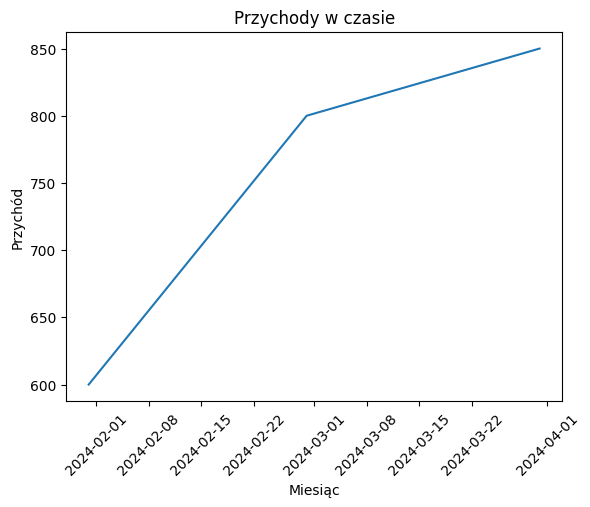

In [39]:
plt.plot(revenue_by_month.index, revenue_by_month.values)
plt.title("Przychody w czasie")
plt.xlabel("Miesiąc")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()

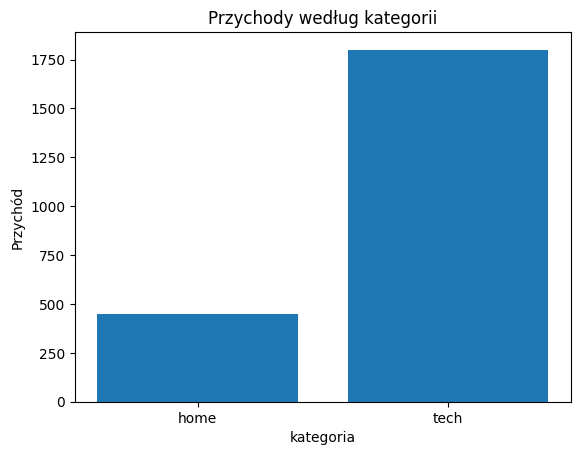

In [45]:
plt.bar(revenue_by_category.index, revenue_by_category.values)
plt.title("Przychody według kategorii")
plt.xlabel("kategoria")
plt.ylabel("Przychód")
plt.show()

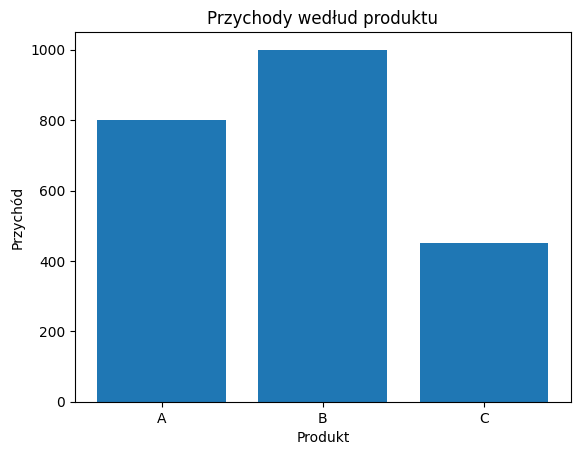

In [50]:
plt.bar(revenue_by_product.index, revenue_by_product.values)
plt.title("Przychody wedłud produktu")
plt.xlabel("Produkt")
plt.ylabel("Przychód")
plt.show()